# Epic of Sun - Desafio 1
Training  the model.
***

This jupyter notebook trains a UNet for sugarcane identification from satellite images.

It is divided in 6 parts:
* Loading libraries and data
* Separating the dataset in train, validate, and test sets
* Build the model
* Train the model
* Evaluate the model

***

## Loading libraries and data

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
import rasterio
from rasterio.features import rasterize

import json
import joblib
from pathlib import Path
import os

import tensorflow as tf
from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

import keras_tuner as kt

from sklearn.metrics import (
	classification_report, 
	confusion_matrix, 
	roc_auc_score,
	roc_curve,
	precision_recall_curve, 
    precision_score,
    recall_score,
    f1_score,
	recall_score)

In [2]:
# Get the directory where THIS script is located
base_path = Path.cwd()

In [3]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

In [4]:
patch_index = pd.read_csv(patches_path / "patch_index.csv" )

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene02         0          0          0   
1  scene02         1          0         64   
2  scene02         2          0        128   
3  scene02         3          0        192   
4  scene02         4          0        256   

                                   x_patch_path  \
0  data/processed/scene02/images/patch_0000.npy   
1  data/processed/scene02/images/patch_0001.npy   
2  data/processed/scene02/images/patch_0002.npy   
3  data/processed/scene02/images/patch_0003.npy   
4  data/processed/scene02/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene02/masks/patch_0000.npy             13141  
1  data/processed/scene02/masks/patch_0001.npy             11845  
2  data/processed/scene02/masks/patch_0002.npy              8973  
3  data/processed/scene02/masks/patch_0003.npy              5129  
4  data/processed/scene02/masks/patch_0004.npy              1410  
2318


## Separating the dataset in train, validate, and test sets

In [5]:
# Random split for one Sentinel scene
# With more scenes, split by scene, not by patch.

# Split the dataset into training and test sets
train_df, test_df = train_test_split(
    patch_index,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Split the training set into training and validation sets
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Function to add spectral indices to the input patches

def add_spectral_indices(X_data, eps=1e-8):
    """
    Appends spectral indices (NDVI, NDWI, EVI) as extra channels to input patches.
    
    Expected input shape: (..., H, W, 4) or (H, W, 4)
    Channels: [Blue (0), Green (1), Red (2), NIR (3)]
    """
    # Extract individual bands along the last axis
    blue  = X_data[..., 0]
    green = X_data[..., 1]
    red   = X_data[..., 2]
    nir   = X_data[..., 3]

    # 1. NDVI: (NIR - Red) / (NIR + Red)
    ndvi = (nir - red) / (nir + red + eps)

    # 2. NDWI: (Green - NIR) / (Green + NIR)
    ndwi = (green - nir) / (green + nir + eps)

    # 3. EVI: 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)

    # Re-add channel dimension to calculated 2D indices
    ndvi = np.expand_dims(ndvi, axis=-1)
    ndwi = np.expand_dims(ndwi, axis=-1)
    evi  = np.expand_dims(evi, axis=-1)

    # Stack original bands with new index channels along the channel axis
    X_expanded = np.concatenate([X_data, ndvi, ndwi, evi], axis=-1)

    return X_expanded

In [ ]:
# Function to load the patches individually

def load_dataset(df, base_path, compute_indices=True):
    """
    Loads .npy patches listed in a DataFrame into memory as NumPy arrays.
    
    Parameters:
        df (pd.DataFrame): Dataframe slice (train, val, or test) containing patch paths.
        base_path (Path): Root project directory to resolve relative file paths.
    """
    X = []
    Y = []

    for _, row in df.iterrows():
        # Resolve path relative to base_path (or remove base_path / if paths in CSV are absolute)
        x_path = base_path / row["x_patch_path"]
        y_path = base_path / row["y_patch_path"]

        x = np.load(x_path).astype(np.float32)
        y = np.load(y_path).astype(np.float32)

        X.append(x)
        Y.append(y)

    # Stack into 4D arrays: (N, H, W, C)
    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

	# Append spectral indices if requested
    if compute_indices:
        X = add_spectral_indices(X)

    return X, Y

In [ ]:
# Load the datasets

# Pass base_path so Path resolution works smoothly across notebooks
X_train, y_train = load_dataset(train_df, base_path, compute_indices=True)
X_val, y_val = load_dataset(val_df, base_path, compute_indices=True)
X_test, y_test = load_dataset(test_df, base_path, compute_indices=True)

X_train shape: (1483, 128, 128, 4)
y_train shape: (1483, 128, 128, 1)


In [ ]:
# Print the shapes and data types of the datasets
# Shape will now be (N, 128, 128, 7) -> [Blue, Green, Red, NIR, NDVI, NDWI, EVI]
print("Training set:")
print(X_train.shape)
print(y_train.shape)

print(X_train.dtype)
print(y_train.dtype)

print("\nValidation set:")
print(X_val.shape)
print(y_val.shape)

print(X_val.dtype)
print(y_val.dtype)

print("\nTest set:")
print(X_test.shape)
print(y_test.shape)

print(X_test.dtype)
print(y_test.dtype)

print(np.unique(y_train))

Training set:
(1483, 128, 128, 4)
(1483, 128, 128, 1)
float32
float32

Validation set:
(371, 128, 128, 4)
(371, 128, 128, 1)
float32
float32

Test set:
(464, 128, 128, 4)
(464, 128, 128, 1)
float32
float32
[0. 1.]


In [18]:
# Print the first row of the patch index
print(patch_index.iloc[0])

scene                                                    scene02
patch_id                                                       0
row_start                                                      0
col_start                                                      0
x_patch_path        data/processed/scene02/images/patch_0000.npy
y_patch_path         data/processed/scene02/masks/patch_0000.npy
sugarcane_pixels                                           13141
Name: 0, dtype: object


## Build the Model

In [19]:
# Convolution block
# Each block performs Conv -> ReLU -> Conv -> ReLU

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x

In [20]:
# Encoder block
# Each block performs:
#  extracts features
#  saves them for the skip connection
#  downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [21]:
# Decoder block
# Each block performs:
#  upsamples
#  concatenates the skip connection
#  performs two convolutions

def decoder_block(inputs, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)
	
    x = layers.Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

In [ ]:
# Function to build the network, compile it, use tunned hyperparameters, and return the model

def build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)  # 32
    s2, p2 = encoder_block(p1, init_filters * 2)  # 64
    s3, p3 = encoder_block(p2, init_filters * 4)  # 128
    s4, p4 = encoder_block(p3, init_filters * 8)  # 256
    
    # Bottleneck
    b1 = conv_block(p4, init_filters * 16)        # 512
    
    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)  # 256
    d2 = decoder_block(d1, s3, init_filters * 4)  # 128
    d3 = decoder_block(d2, s2, init_filters * 2)  # 64
    d4 = decoder_block(d3, s1, init_filters)      # 32
    
    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)
    
    # Unified comilation with the original metrics
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )
    return model

In [23]:
# Wrapper function for Keras Tuner to tune hyperparameters

def tune_wrapper(hp):
    # Define the hyperparameters to tune
	# 1. Structural hyperparameters
    hp_filters = hp.Choice("init_filters", values=[8, 16, 32, 64])
    hp_lr = hp.Float("lr", min_value=1e-5, max_value=1e-2, sampling="log")
    
	# 2. Training hyperparameter (Focused on hardware economy)
    hp.Choice("batch_size", values=[8, 16, 32, 64]) 

    # Call original build_unet function with the hyperparameters
    return build_unet(init_filters=hp_filters, lr=hp_lr)

In [24]:
# Hyperparameter search

# Custom Tuner that successfully extracts and applies the batch size
class CustomRandomSearch(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        # Safely pull the active hyperparameter sample assigned by Keras Tuner
        hp = trial.hyperparameters
        
        # Inject it into kwargs so tf.keras.Model.fit receives it smoothly
        kwargs['batch_size'] = hp.get('batch_size') 
        return super(CustomRandomSearch, self).run_trial(trial, *args, **kwargs)

# Configuration for low processing
tuner = CustomRandomSearch(
    tune_wrapper,
    objective="val_loss",
    max_trials=30, # Number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory="unet_tuner_results", # Directory to store the results of the hyperparameter search
    project_name="sugarcane_fast",
	overwrite=True # Cleans up older, failed configuration caches
)

# Stop early if the model is not improving to save time
fast_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2)

# Execute the hyperparameter search
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
	callbacks=[fast_stop]
)

# Extract and print the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best learning rate: {best_hps.get('lr')}")
print(f"Best init_filters:  {best_hps.get('init_filters')}")
print(f"Best batch_size:    {best_hps.get('batch_size')}")

# Save data in JSON file
best_params = {
	"lr": best_hps.get("lr"), 
	"init_filters": best_hps.get("init_filters"),
	"batch_size": int(best_hps.get("batch_size"))
	}

json_path = base_path / "models" / "best_sugarcane_params.json"
with open(json_path, "w") as f:
    json.dump(best_params, f)
print(f"Best hyperparameters saved to {json_path}")

Trial 30 Complete [00h 03m 05s]
val_loss: 0.22196125984191895

Best val_loss So Far: 0.19823865592479706
Total elapsed time: 00h 40m 53s
Best learning rate: 0.00017087159858278722
Best init_filters:  64
Best batch_size:    8
Best hyperparameters saved to /home/fdesmello/Git/spacesugar/models/best_sugarcane_params.json


In [35]:
# Create the model with the best hyperparameters

# Load the best hyperparameters from the JSON file
with open(json_path, "r") as f:
    saved_params = json.load(f)

# Create the model with the best hyperparameters
model = build_unet(
    init_filters=saved_params["init_filters"], 
    lr=saved_params["lr"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 128, 128,  │      2,368 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_38[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ conv2d_39[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_40[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ conv2d_41[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_9[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_42[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 16, 16,    │          0 │ conv2d_43[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_10… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_44[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 8, 8, 512) │          0 │ conv2d_45[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_11… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 8, 8,      │  9,438,208 │ conv2d_46[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 16, 16,    │  2,097,664 │ conv2d_47[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,032,321 (118.38 MB)

 Trainable params: 31,032,321 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# You can just load the model if already trained and not run the random search and best model again

model_path = base_path / "models" / "unet_sugarcane.keras"

# Print and check if the path actually exists on disk
print(f"Target path: {model_path}")
print(f"File exists: {model_path.exists()}")

if model_path.exists():
    try:
        # Pass str(model_path) to ensure compatibility
        model = load_model(str(model_path), compile=False)
        print("Successfully loaded saved model.")
    except Exception as e:
        print(f"File exists, but load_model failed with error:\n{e}")
else:
    print("File does not exist at the specified path. Check your working directory or base_path.")

Target path: /home/fdesmello/Git/spacesugar/models/unet_sugarcane.keras
File exists: True
Successfully loaded saved model.


## Train the model

In [36]:
# Checkpoint callback to save the best model based on validation loss
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [37]:
# Checkpoint callback to save the best model based on validation loss
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [38]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [39]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=saved_params["batch_size"],
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 34s 138ms/step - binary_accuracy: 0.7544 - loss: 0.4945 - precision_4: 0.7303 - recall_4: 0.7019 - val_binary_accuracy: 0.8485 - val_loss: 0.3495 - val_precision_4: 0.8876 - val_recall_4: 0.7359 - learning_rate: 1.7087e-04
Epoch 2/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - binary_accuracy: 0.8584 - loss: 0.3358 - precision_4: 0.8377 - recall_4: 0.8419 - val_binary_accuracy: 0.8808 - val_loss: 0.2906 - val_precision_4: 0.9101 - val_recall_4: 0.7976 - learning_rate: 1.7087e-04
Epoch 3/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - binary_accuracy: 0.8795 - loss: 0.2945 - precision_4: 0.8608 - recall_4: 0.8667 - val_binary_accuracy: 0.9074 - val_loss: 0.2427 - val_precision_4: 0.8819 - val_recall_4: 0.9026 - learning_rate: 1.7087e-04
Epoch 4/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - binary_accuracy: 0.8966 - loss: 0.2669 - precision_4: 0.8801 - recall_4: 0.8860 - val_binary_accuracy: 0.9178 - val_loss: 0.2255 - val_precision_4: 0.8921

In [40]:
# Save the model
model.save(base_path / "models" / "unet_sugarcane.keras")

## Evaluate the model


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/loss_accuracy.png'


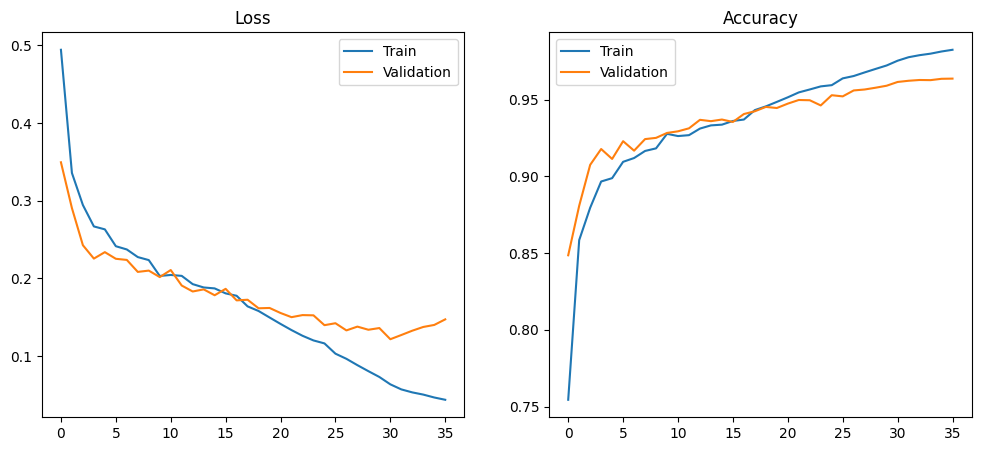

In [41]:
# Plot the learning curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["binary_accuracy"], label="Train")
plt.plot(history.history["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / "loss_accuracy.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()

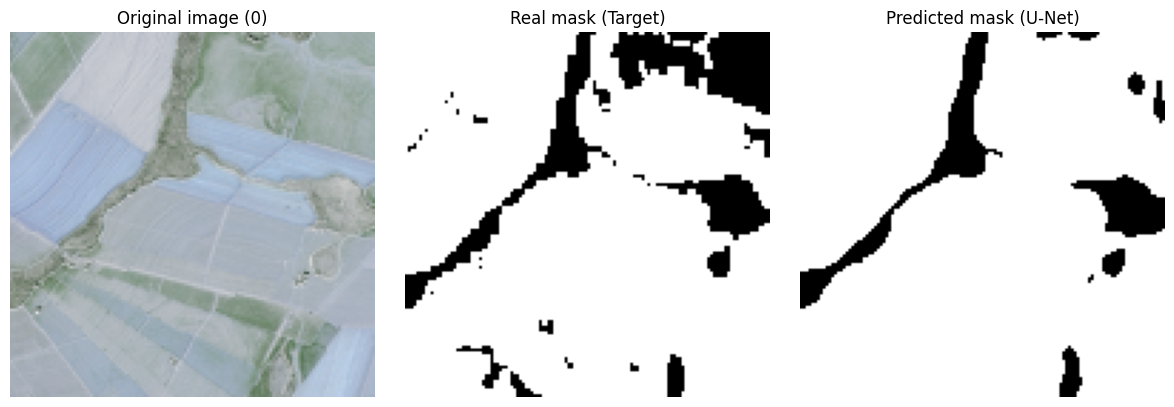

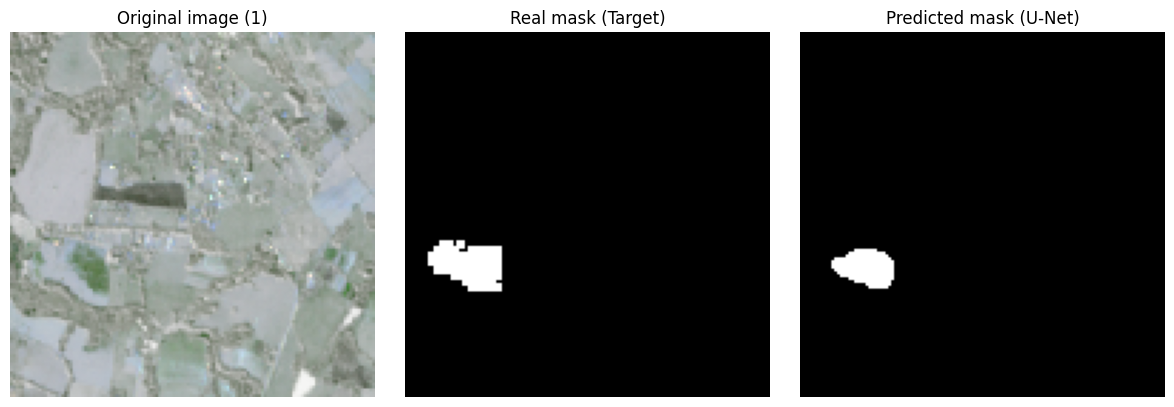

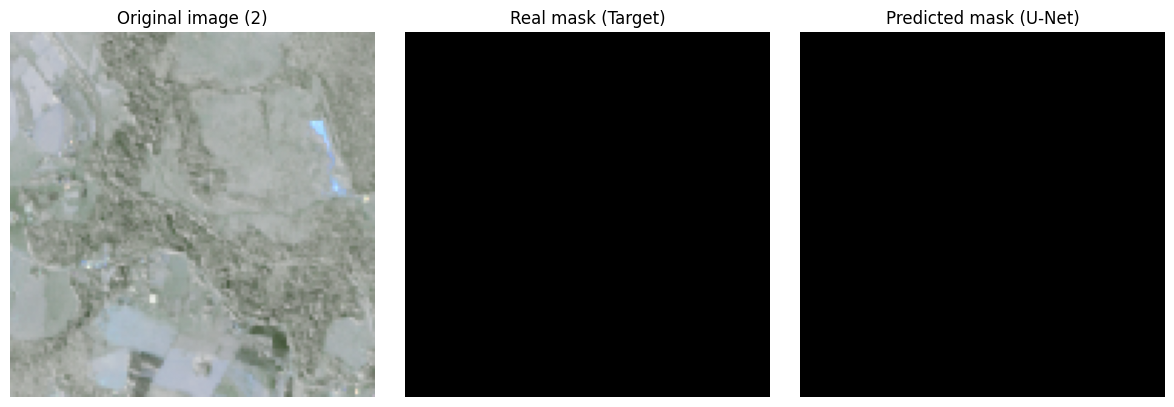

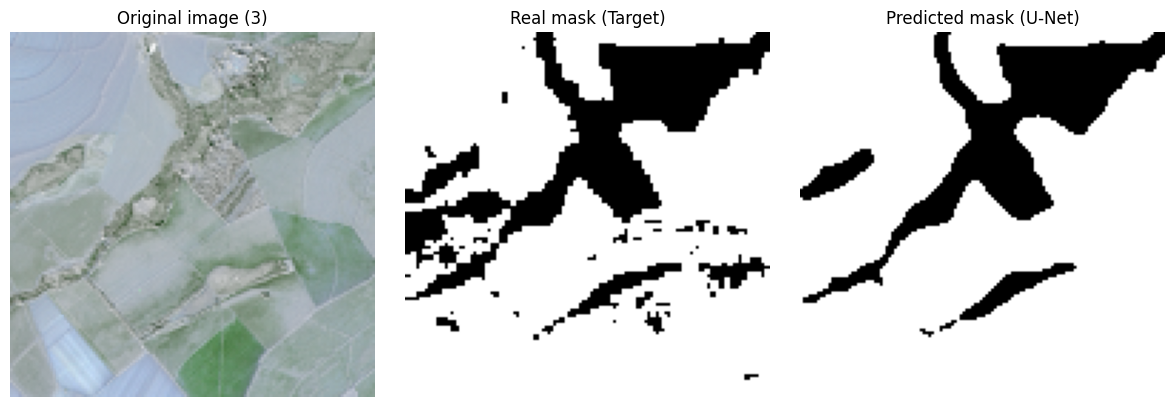

In [42]:
# Visualize the results

max_plots = 4  # Number of images to visualize

all_predictions = [] # List to accumulate all predictions

for i in range(len(X_test)):
    # 1. Extract the single image and make a prediction
    single_img = X_test[i][np.newaxis, ...]
    pred = model.predict(single_img, verbose=0)
    
    # Remove the batch dimension
    pred_squeezed = pred[0]
    all_predictions.append(pred_squeezed) # Save to list for global metrics
    
    # 2. VISUALIZATION SETUP (Only for the first X images)
    if i < max_plots:
        binary_pred = pred_squeezed > 0.5
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        
        ax[0].imshow(X_test[i])
        ax[0].set_title(f"Original image ({i})")
        ax[0].axis('off')
        
        ax[1].imshow(y_test[i].squeeze(), cmap='gray')
        ax[1].set_title("Real mask (Target)")
        ax[1].axis('off')
        
        ax[2].imshow(binary_pred.squeeze(), cmap='gray')
        ax[2].set_title("Predicted mask (U-Net)")
        ax[2].axis('off')
        
        file_path = base_path / "figures" / "unet_sugarcane_results_{i}.png"
        plt.savefig(file_path, dpi=300, bbox_inches='tight')

        plt.tight_layout()
        plt.show()

In [43]:
# Metrics Calculation

# 1. Convert all collected predictions into a matching NumPy array
# Shape will become (N, H, W, C) matching y_train
y_pred_all = np.array(all_predictions)

# 2. Transform both entire sets into binary integers
y_pred_bin = (y_pred_all > 0.5).astype(int)
y_true_bin = y_test.astype(int)

# 3. Flatten the entire sets to 1D arrays
y_true_flat = y_true_bin.ravel()
y_pred_flat = y_pred_bin.ravel()

# 3.5. Calculate float probailities
y_true_float = y_test.astype(float).ravel()
y_pred_float = y_pred_all.astype(float).ravel()

# 4. Calculate global metrics
p = precision_score(y_true_flat, y_pred_flat, zero_division=0)
r = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
roc_auc = roc_auc_score(y_true_flat, y_pred_flat)

print(f"Metrics for the entire dataset:")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)
print("\nConfusion Matrix:")
print(cm)

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_true_flat, y_pred_flat, zero_division=0))

Metrics for the entire dataset:
Precision: 0.9399
Recall: 0.9629
F1-Score: 0.9513
ROC AUC Score: 0.9596

Confusion Matrix:
[[4252992  194151]
 [ 117131 3037902]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96   4447143
           1       0.94      0.96      0.95   3155033

    accuracy                           0.96   7602176
   macro avg       0.96      0.96      0.96   7602176
weighted avg       0.96      0.96      0.96   7602176



/tmp/ipykernel_62563/2134881472.py:72: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_62563/2134881472.py:75: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(file_path, dpi=300, bbox_inches='tight')



Visualization saved as '/home/fdesmello/Git/spacesugar/figures/unet_sugarcane_results.png'


/home/fdesmello/miniconda3/envs/sugarcane/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


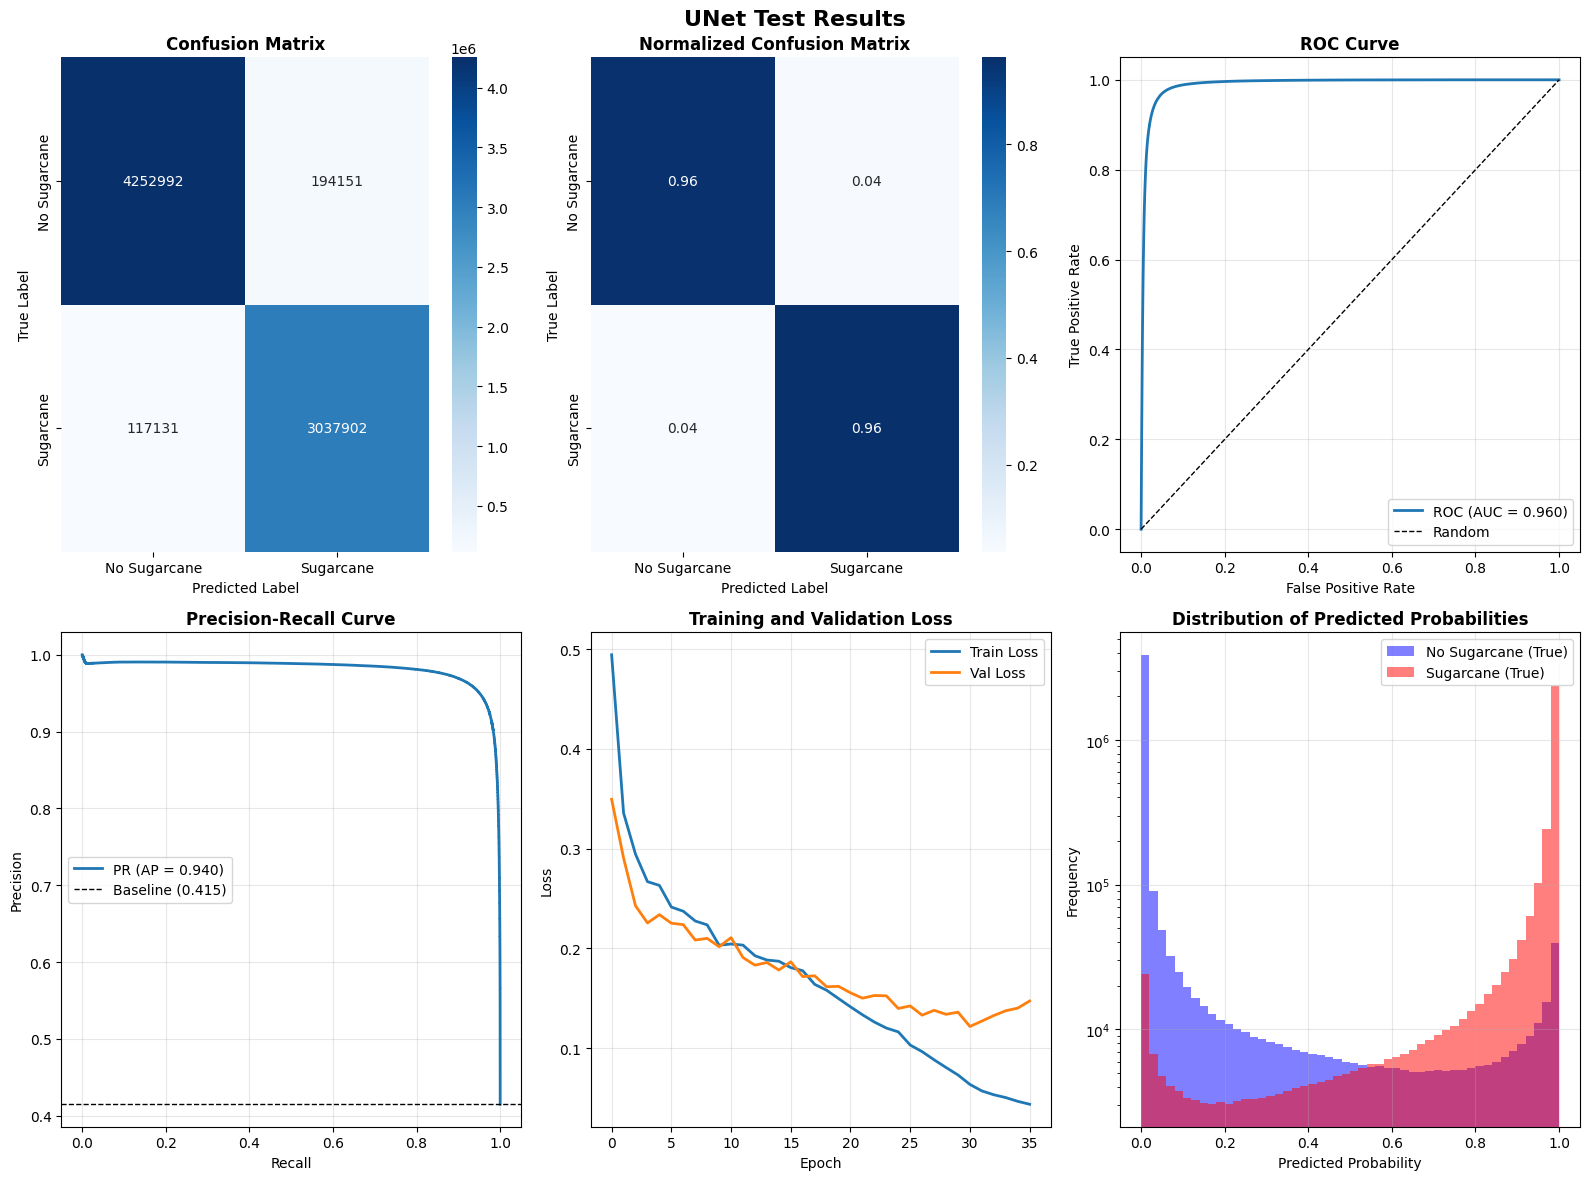

In [44]:
# Visualizations

fig = plt.figure(figsize=(16, 12))
plt.suptitle('UNet Test Results', fontsize=16, fontweight='bold')

class_names = ['No Sugarcane', 'Sugarcane']

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=class_names, yticklabels=class_names)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
cm_norm = pd.DataFrame(cm).apply(lambda x: x/sum(x), axis = 1)
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues', ax=ax2, xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. ROC Curve
if len(np.unique(y_true_float)) > 1:
    ax3 = plt.subplot(2, 3, 3)
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_float)
    ax3.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Precision-Recall Curve
if len(np.unique(y_true_float)) > 1:
    ax4 = plt.subplot(2, 3, 4)
    precision, recall, _ = precision_recall_curve(y_true_flat, y_pred_float)
    ax4.plot(recall, precision, linewidth=2, label=f'PR (AP = {p:.3f})')
    ax4.axhline(y=y_true_flat.mean(), color='k', linestyle='--', linewidth=1, 
                label=f'Baseline ({y_true_flat.mean():.3f})')
    ax4.set_xlabel('Recall')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

# 5. Training and Validation Loss
if 'history' in locals():
    hist = history.history
    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(hist['loss'], label='Train Loss', linewidth=2)
    if 'val_loss' in hist:
        ax5.plot(hist['val_loss'], label='Val Loss', linewidth=2)
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Loss')
    ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 6. Prediction Probability Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_pred_float[y_true_flat == 0], bins=50, alpha=0.5, label='No Sugarcane (True)', color='blue')
ax6.hist(y_pred_float[y_true_flat == 1], bins=50, alpha=0.5, label='Sugarcane (True)', color='red')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
ax6.set_yscale('log')
ax6.set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()

file_path = base_path / "figures" / "unet_sugarcane_results.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()